# Customized Deployment Pipeline for Semantic Models

> **Purpose:** This notebook provides a **flexible, automated, and parameter-driven** approach for deploying **semantic models** across Microsoft Fabric workspaces—supporting scenarios from **Development ➜ Test ➜ Production**, one-to-many, many-to-one, and many-to-many deployments.


<details>
  <summary><b style="font-size: 18px;">✨ Key Capabilities</b></summary>

- **Multi-Model Support**  
  Deploy multiple semantic models in a single run.

- **Flexible Workspace Topologies**  
  - **One source ➜ many targets** (e.g., Dev ➜ Test + Prod)  
  - **Many sources ➜ one or many targets** (e.g., Team Workspaces ➜ Central Prod)

- **Parametrized & Automatable**  
  Everything can be driven by parameters—ideal for scheduled or CI/CD-triggered runs.

- **Environment Promotion**  
  Promote validated models across environments with consistent governance.
  
</details>

<details>
  <summary><b style="font-size: 18px;">✅ Benefits</b></summary>

- **Efficiency:** Reduce manual steps and error risk.  
- **Consistency:** Ensure uniform models and configurations across environments.  
- **Scalability:** Handle complex topologies and multiple models at once.  
- **Repeatability:** Parameterized runs enable deterministic deployments.
- **Traceability:** Activities can be logged, enabling auditing, troubleshooting, and historical tracking of changes.

</details>

<details>
  <summary><b style="font-size: 18px;">📦 Use Cases</b></summary>

- **Multi-Environment Deployments**
  - Perfect for organizations that maintain separate development, QA, and production environments and need to promote semantic models through these stages.
  <br><br>
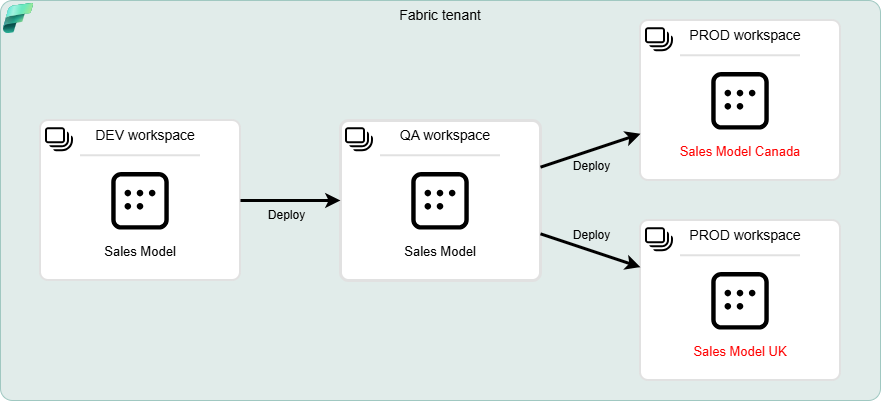
  <br>
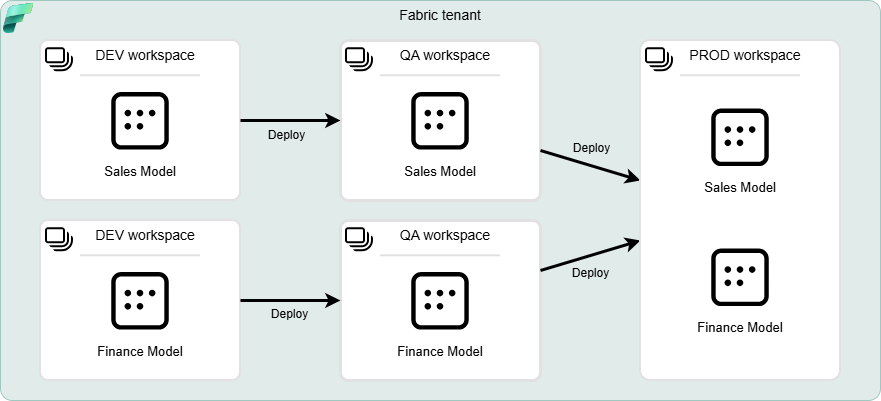
  <br>
- **Cross-Tenant Deployments**
  - With modifications, can support deployments across different Microsoft 365 tenants (with proper authentication changes).
<br><br>
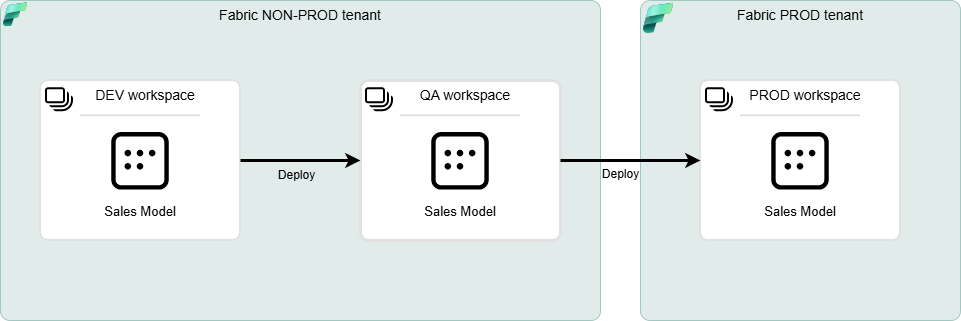
<br>
- **Companies without a Fabric license**
  - Organizations that do not have a Fabric license can still benefit from this solution by:
    - Downloading the notebook locally
    - Installing the required Python dependencies
    - Running the deployment logic using local Python execution

- **No Azure DevOps Access**
  - Ideal for projects where:
    - Azure DevOps pipelines are not available
    - IT restrictions prevent DevOps tool usage
    - The organization lacks DevOps licensing

- **Custom Deployment Logic**
  - When you need:
    - Selective model deployment (specific models only)
    - Custom parameter transformation between environments
    - Pre/post-deployment validation
    - Deployment logging and auditing

- **Batch Deployments**
  - Efficiently deploy multiple semantic models in a single operation:

- **Scheduled Deployments**
  - Can be scheduled to run automatically using:
    - Fabric Notebooks with scheduled runs
    - Azure Data Factory pipelines
    - Power Automate flows

</details>


##### **PART 1 – Dependencies & Authentication**
Install **semantic-link-labs**, the Microsoft Fabric Python SDK that provides helpers for TOM (Tabular Object Model) connections and Direct Lake operations.
This package is not pre-installed in Fabric notebooks, so it must be installed at runtime via `%pip` before the first import for demo purpuses.
Ideally, all dependencies should be configured on the workspace environment.

In [ ]:
# Install dependency package for TOM (Tabular Object Model) connections and Direct Lake operations.
# Comment line below if package is already installed in the environment, otherwise it will be installed at runtime.
%pip install semantic-link-labs

# Core imports
import sempy_labs as labs               # Fabric/TOM helper library
from notebookutils import mssparkutils  # Fabric notebook utilities (token acquisition, etc.)
import requests                         # HTTP client for REST API calls
import time                             # Used for polling delays (Retry-After header)
import json                             # JSON serialisation/deserialisation

# ── API base endpoints ────────────────────────────────────────────────────────
# Fabric REST API  – workspace / semantic-model operations
fabrid_endpoint = "https://api.fabric.microsoft.com"
# Power BI REST API – datasource & parameter update operations
powerbi_endpoint = "https://api.powerbi.com"

# ── Authentication ────────────────────────────────────────────────────────────
# Obtain a bearer token scoped to the Fabric endpoint using the notebook's
# managed identity / logged-in user via mssparkutils.
# The same token is accepted by both the Fabric and Power BI REST APIs.
access_token = mssparkutils.credentials.getToken(fabrid_endpoint)

# All HTTP requests share this header dictionary.
headers = {"Authorization": f"Bearer {access_token}"}


StatementMeta(, 14facb81-f443-4418-a9c6-89a90a5cf433, 8, Finished, Available, Finished, False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/859.8 kB ? eta -:--:--Requirement already satisfied: msgpack>1.0 in /home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages (from fluent-logger->synapseml-utils->fabric-analytics-notebook-plugin->fabric-analytics-sdk[online-notebook]<1.0.0,>=0.0.2->semantic-link-sempy>=0.13.0->semantic-link-labs) (1.0.3)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.8/859.8 kB 18.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.2/125.2 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.

##### **PART 2 – Deployment Parameters** *(actual run configuration)*

Edit the cell below to match your environment.

**Structure overview**

```
deployment_params
├── source                         # Where to read semantic models from
│   ├── workspaces[]               # One or more source workspaces
│   │   ├── workspace_name         # Display name of the Fabric workspace
│   │   ├── semantic_models[]      # Models to deploy from this workspace
│   │   │   ├── semantic_model_name
│   │   │   └── datasources[]      # Model-level datasource override (optional)
│   │   └── datasources[]          # Workspace-level datasource override (optional)
│   └── datasources[]              # Global datasource fallback (optional)
│
└── target                         # Where to deploy semantic models to
    ├── workspaces[]               # One or more target workspaces
    │   ├── workspace_name
    │   ├── semantic_models[]
    │   │   ├── semantic_model_name
    │   │   ├── datasources[]      # Model-level connection remapping (optional)
    │   │   └── parameters[]       # Model-level parameter overrides (optional)
    │   ├── datasources[]          # Workspace-level connection remapping (optional)
    │   └── parameters[]           # Workspace-level parameter overrides (optional)
    ├── datasources[]              # Global connection remapping fallback (optional)
    └── parameters[]               # Global parameter overrides fallback (optional)
```

**Hierarchy resolution** (most-specific wins): `model-level > workspace-level > global-level`

**`datasources[]` format** mirrors the Power BI UpdateDatasources API payload:
- `source side` → `{ datasourceType, connectionDetails: { server | path, database | url } }`
- `target side` → `{ datasourceType, connectionDetails: { server | path, database | url } }`

References: [UpdateDatasources](https://learn.microsoft.com/en-us/rest/api/power-bi/refresh-datasets/update-datasources) · [GetDatasources](https://learn.microsoft.com/en-us/rest/api/power-bi/datasets/get-datasources-in-group)

**`parameters[]` format:** `{ "parameter_name": "<param name>", "new_value": "<value for target env>" }`

In [4]:
# Run configuration: define source and target details for the deployment, including
# workspace and model names, parameter updates, and datasource remapping connection details. 
deployment_params = {
    "source": {
        "workspaces": [
            {
                "workspace_name": "Lab_PBI_Rodrigo_Dev",
                "semantic_models": [
                    {
                        # Import model example: datasource connection details are declared here so the source
                        # endpoint can be used as the datasourceSelector when remapping to the target.
                        "semantic_model_name":"Sales_Model_LH_Import",
                        "datasources": [
                            {
                                "datasourceType": "Sql",
                                "connectionDetails": {
                                    "server": "rtdp5ojnzepenguxhub2b4mlqi-f73nifnzi7puxcy4usjbesflr4.datawarehouse.fabric.microsoft.com",
                                    "database": "lakehouse_wwi"
                                }
                            }
                        ]
                    },
                    {
                        # Direct Lake model example: no datasource remapping needed here –
                        # the connection is managed via the Direct Lake API at deploy time.
                        # Process will search in target workspace for the SQL endpoint with 
                        # the same name as the source for the model's connection.
                        "semantic_model_name":"Sales_Model_LH_DirectLake"
                    }
                ]
            }
        ],
        # Global-level datasource fallback (used when a model/workspace
        # does not declare its own datasources list).
        "datasources": [
            {
                "datasource_type": "Sql",
                "connection_details": {
                    "server": "My-Sql-Server",
                    "database": "My-Sql-Database"
                }
            },
            {
                "datasource_type": "OData",
                "connection_details": {
                    "url": "http://services.odata.org/V4/Northwind/Northwind.svc"
                }
            }
        ]
    },
    "target": {
        "workspaces": [
            {
                "workspace_name": "Lab_PBI_Rodrigo_Test",
                "semantic_models": [
                    {
                        "semantic_model_name":"Sales_Model_LH_Import",
                        # Parameters to update after deployment via the
                        # Power BI UpdateParameters API.
                        "parameters": [
                            {
                                "parameter_name": "p_Workspace_Name",
                                "new_value": "QA_Workspace"
                            },
                            {
                                "parameter_name": "p_Database_Name",
                                "new_value": "QA_Database"
                            }
                        ],
                        # Target datasource connection details. These are paired
                        # by index with the source datasources to build the
                        # UpdateDatasources payload (datasourceSelector → connectionDetails).
                        "datasources": [
                            {
                                "datasourceType": "Sql",
                                "connectionDetails": {
                                    "server": "rtdp5ojnzepenguxhub2b4mlqi-wcqtclskrzyefkmpejznhji5iu.datawarehouse.fabric.microsoft.com",
                                    "database": "lakehouse_wwi"
                                }
                            }
                        ]
                    },
                    {
                        # Direct Lake model in target: no datasource/parameter
                        # overrides needed – connection is set dynamically.
                        "semantic_model_name":"Sales_Model_LH_DirectLake",
                        "parameters": [],
                        "datasources": []
                    }
                ],
                # Workspace-level fallbacks (empty here – model-level values take precedence)
                "parameters": [],
                "datasources": []
            }
        ],
        # Global-level parameter fallback
        "parameters": [
            {
                "parameter_name": "p_Workspace_Name",
                "new_value": "QA_Workspace"
            },
            {
                "parameter_name": "p_Database_Name",
                "new_value": "QA_Database"
            }
        ],
        # Global-level datasource fallback
        "datasources": [
            {
                "datasource_type": "Sql",
                "connection_details": {
                    "server": "New-Sql-Server",
                    "database": "New-Sql-Database"
                }
            },
            {
                "datasource_type": "OData",
                "connection_details": {
                    "url": "http://services.odata.org/V4/Odata/Northwind.svc"
                }
            }
        ]        
    }
}


StatementMeta(, 14facb81-f443-4418-a9c6-89a90a5cf433, 10, Finished, Available, Finished, False)

##### **PART 3 – Workspace & Semantic Model Resolution**

Steps performed in this cell:

1. Fetch all workspaces accessible to the current user via the Fabric API.
2. Filter to the source and target workspaces declared in `deployment_params`.
3. Build a **source config map** (model name → workspace id + datasource config).
4. Fetch all semantic models in each source workspace; add a **stub entry** for any model not yet created (so the deploy loop can still run the first time).
5. Build a **target config map** (model name → workspace id + `UpdateDatasources` payload + `UpdateParameters` payload, pre-formatted for the Power BI API).
6. Fetch all semantic models in each target workspace; same stub pattern.

In [ ]:
# ── Step 1: Fetch the full workspace list ─────────────────────────────────────
workspace_resp = requests.get(f'{fabrid_endpoint}/v1/workspaces', headers=headers)
workspace_resp.raise_for_status()

workspace_data = workspace_resp.json().get('value')

# ── Step 2a: Resolve source workspaces ───────────────────────────────────────
# Extract workspace names declared in the source section of deployment_params.
source_workspace_names = [workspaces.get('workspace_name') 
                          for workspaces in deployment_params.get('source').get('workspaces')
                          if isinstance(workspaces, dict) and "workspace_name" in workspaces]

# Filter the full workspace list to keep only those that are source workspaces.
source_workspaces = [workspace for workspace in workspace_data
                     if workspace.get("displayName") in source_workspace_names]

# ── Step 2b: Resolve target workspaces ───────────────────────────────────────
target_workspace_names = [workspaces.get('workspace_name') 
                          for workspaces in deployment_params.get('target').get('workspaces')
                          if isinstance(workspaces, dict) and "workspace_name" in workspaces]

target_workspaces = [workspace for workspace in workspace_data
                     if workspace.get("displayName") in target_workspace_names]

# ── Step 3: Build source semantic model configuration map ────────────────────
# Produces a dict keyed by model name. Each entry contains:
#   - workspace_name / workspace_id  : where the model lives in the source
#   - datasources                    : connection details for this model
#                                      (model-level > workspace-level > global fallback)
source_semantic_model_config = {}
global_datasources = deployment_params.get("source").get("datasources", [])
for workspace in deployment_params.get("source").get("workspaces", []):
    if isinstance(workspace, dict) and "semantic_models" in workspace:
        workspace_name = workspace.get("workspace_name")
        # Resolve the workspace GUID from the API response using its display name.
        workspace_id = next((w.get("id") for w in source_workspaces if w.get("displayName") == workspace_name), None)
        # Workspace-level datasource override; falls back to global if not set.
        workspace_datasources = workspace.get("datasources", global_datasources)
        
        for semantic_model in workspace.get("semantic_models", []):
            if isinstance(semantic_model, dict) and "semantic_model_name" in semantic_model:
                model_name = semantic_model.get("semantic_model_name")
                # Model-level datasource override; falls back to workspace-level.
                semantic_model_datasources = semantic_model.get("datasources", workspace_datasources)
                source_semantic_model_config[model_name] = {
                    "workspace_name": workspace_name,
                    "workspace_id": workspace_id,
                    "semantic_model_name": model_name,
                    "datasources": semantic_model_datasources
                }

source_semantic_model_names = list(source_semantic_model_config.keys())

# ── Step 4: Fetch source semantic models (with stub fallback) ─────────────────
# For each model in the config map, query the Fabric API.
# If the model is not found (e.g. first deployment), insert a stub dict so that
# downstream cells can still reference it without KeyError/AttributeError.
source_semantic_models = []
for model_name, config in source_semantic_model_config.items():
    source_workspace_id = config.get("workspace_id")
    source_workspace_name = config.get("workspace_name")

    source_semantic_model_resp = requests.get(f"{fabrid_endpoint}/v1/workspaces/{source_workspace_id}/semanticModels", headers=headers)
    source_semantic_model_resp.raise_for_status()

    source_semantic_model_data = source_semantic_model_resp.json().get("value")

    # Try to find the model in the source workspace by display name.
    existing_model = next((m for m in source_semantic_model_data if m.get("displayName") == model_name), None)

    if existing_model:
        # Model exists: enrich the API response object with datasource config
        # so it is available later without an extra lookup.
        existing_model["_workspace_name"] = source_workspace_name
        existing_model["_datasources_config"] = config.get("datasources", [])
        source_semantic_models.append(existing_model)
    else:
        # Model not yet in source workspace: create a minimal stub.
        # The stub carries enough context for the deployment loop to identify
        # the intended model, but has no 'id' field (id=None signals "does not exist").
        source_semantic_models.append({
            "displayName": model_name,
            "workspaceId": source_workspace_id,
            "_workspace_name": source_workspace_name,
            "_datasources_config": config.get("datasources", [])
        })

# ── Step 5: Build target semantic model configuration map ────────────────────
# Similar to the source map, but additionally pre-builds API-ready payloads:
#
#   _datasources_config  →  Power BI UpdateDatasources format:
#       { "updateDetails": [
#           { "datasourceSelector": { datasourceType, connectionDetails },  ← source
#             "connectionDetails":  { server | path, database | url }              ← target
#           }, ...
#       ]}
#       Source and target datasources are paired positionally (by index).
#
#   _parameters_config   →  Power BI UpdateParameters format:
#       { "updateDetails": [
#           { "name": "<param>", "newValue": "<value>" }, ...
#       ]}
target_semantic_model_config = {}
global_datasources = deployment_params.get("target").get("datasources", [])
global_parameters = deployment_params.get("target").get("parameters", [])
for workspace in deployment_params.get("target").get("workspaces", []):
    if isinstance(workspace, dict) and "semantic_models" in workspace:
        workspace_name = workspace.get("workspace_name")
        workspace_id = next((w.get("id") for w in target_workspaces if w.get("displayName") == workspace_name), None)
        # Workspace-level overrides; fall back to globals if not declared.
        workspace_datasources = workspace.get("datasources", global_datasources)
        workspace_parameters = workspace.get("parameters", global_parameters)
        
        for semantic_model in workspace.get("semantic_models", []):
            if isinstance(semantic_model, dict) and "semantic_model_name" in semantic_model:
                model_name = semantic_model.get("semantic_model_name")
                # Model-level overrides; fall back to workspace-level.
                target_datasources = semantic_model.get("datasources", workspace_datasources)
                target_parameters = semantic_model.get("parameters", workspace_parameters)

                # Retrieve the corresponding source datasource list so we can
                # build the datasourceSelector (source fingerprint) for each entry.
                source_config = source_semantic_model_config.get(model_name, {})
                source_datasources = source_config.get("datasources", [])

                # Build the UpdateDatasources payload by pairing source (selector)
                # and target (new connection details) datasources by position.
                datasource_updates = []
                for i, target_ds in enumerate(target_datasources):
                    source_ds = source_datasources[i] if i < len(source_datasources) else {}
                    if target_ds and source_ds:
                        datasource_updates.append({
                            "datasourceSelector": {
                                # Identifies the datasource to replace (must match
                                # what Power BI finds in the published dataset).
                                "datasourceType": source_ds.get("datasourceType"),
                                "connectionDetails": source_ds.get("connectionDetails", {})
                            },
                            # New connection details to apply in the target environment.
                            "connectionDetails": target_ds.get("connectionDetails", {})
                        })

                # Build the UpdateParameters payload from the parameters list.
                parameter_updates = []
                for param in target_parameters:
                    if param.get("parameter_name") and "new_value" in param:
                        parameter_updates.append({
                            "name": param.get("parameter_name"),
                            "newValue": param.get("new_value")
                        })

                target_semantic_model_config[model_name] = {
                    "workspace_name": workspace_name,
                    "workspace_id": workspace_id,
                    # Empty dict means "no update needed" – checked before API call.
                    "_datasources_config": {"updateDetails": datasource_updates} if datasource_updates else {},
                    "_parameters_config": {"updateDetails": parameter_updates} if parameter_updates else {}
                }

target_semantic_model_names = list(target_semantic_model_config.keys())

# ── Step 6: Fetch target semantic models (with stub fallback) ─────────────────
# Same pattern as Step 4 but for the target workspaces.
# Stubs let the deployment loop create new models on first run without errors.
target_semantic_models = []
for model_name, config in target_semantic_model_config.items():
    target_workspace_id = config.get("workspace_id")
    target_workspace_name = config.get("workspace_name")

    target_semantic_model_resp = requests.get(f"{fabrid_endpoint}/v1/workspaces/{target_workspace_id}/semanticModels", headers=headers)
    target_semantic_model_resp.raise_for_status()

    target_semantic_model_data = target_semantic_model_resp.json().get("value")

    # Try to find the model in the target workspace by display name.
    existing_model = next((m for m in target_semantic_model_data if m.get("displayName") == model_name), None)

    if existing_model:
        # Model exists: enrich with datasource and parameter config payloads.
        existing_model["_workspace_name"] = target_workspace_name
        existing_model["_datasources_config"] = config.get("_datasources_config", {})
        existing_model["_parameters_config"] = config.get("_parameters_config", {})
        target_semantic_models.append(existing_model)
    else:
        # Model not yet in target workspace: create a stub.
        # id=None is intentional – exists_in_target checks for id presence
        # to distinguish real models from stubs (see deployment loop).
        target_semantic_models.append({
            "displayName": model_name,
            "workspaceId": target_workspace_id,
            "_workspace_name": target_workspace_name,
            "_datasources_config": config.get("_datasources_config", {}),
            "_parameters_config": config.get("_parameters_config", {})
        })


StatementMeta(, 14facb81-f443-4418-a9c6-89a90a5cf433, 11, Finished, Available, Finished, False)

##### **PART 4 – Deployment Loop**

For every source semantic model resolved in the previous cell:

1. Retrieve the model's PBIP/TMDL definition via the Fabric API.  
   The response may be synchronous (HTTP 200) or asynchronous (HTTP 202).  
   Asynchronous responses are polled using the `Retry-After` / `Location` headers.
2. For each target workspace:  
   a. Check whether the model already exists (has a real `id`, not a stub).  
      - **Exists** → `updateDefinition` (overwrite existing model)  
      - **Missing** → create new model, then apply connection settings  
   b. After creation only, apply post-deployment configuration:  
      - **Direct Lake model** → update the lakehouse/warehouse connection using the `sempy_labs` Direct Lake API. The source item (lakehouse / warehouse) is identified dynamically by matching `type` + `name` from `get_direct_lake_source()` against the target workspace items.  
      - **Import/DirectQuery** → update datasource connections via the Power BI `UpdateDatasources` API, then update parameters via the `UpdateParameters` API.

> **Note:** datasource & parameter updates are skipped when the config dict is empty (no overrides declared in `deployment_params` for that model).

In [ ]:
# For every source semantic model, retrieve the full definition and deploy to each target workspace.
for source_semantic_model in source_semantic_models:
    source_semantic_model_id = source_semantic_model.get("id")
    source_semantic_model_name = source_semantic_model.get("displayName")
    source_workspace_id = source_semantic_model.get("workspaceId")

    # ── Step 1: Get the model definition ──────────────────────────────────────
    # Fabric returns the definition as a list of PBIP parts (JSON/TMDL files).
    # POST is required even for a read operation because the payload can be large.
    definition_resp = requests.post(f"{fabrid_endpoint}/v1/workspaces/{source_workspace_id}/semanticModels/{source_semantic_model_id}/getDefinition", headers=headers)
    definition_resp.raise_for_status()

    if definition_resp.status_code == 200:
        # Synchronous response – definition is in the body.
        semantic_model_definition = definition_resp.json().get("definition")
    
    elif definition_resp.status_code == 202:
        # ── Async polling pattern ──────────────────────────────────────────────
        # Fabric returns 202 Accepted for long-running operations.
        # The Location header points to the status endpoint; alternatively,
        # x-ms-operation-id can be used to build the URL manually.
        operation_location = definition_resp.headers.get("Location")
        operation_id = definition_resp.headers.get("x-ms-operation-id")
        retry_after = int(definition_resp.headers.get("Retry-After", "5"))

        # Prefer Location if present; otherwise build from operation_id
        if operation_location:
            status_url = operation_location
        else:
            status_url = f"{fabrid_endpoint}/v1/operations/{operation_id}"

        # Poll until the operation reaches a terminal state.
        while True:
            time.sleep(retry_after)
            status_resp = requests.get(status_url, headers=headers)
            status = status_resp.json().get("status")
            if status in ("Succeeded", "Failed", "Cancelled"):
                break

        if status != "Succeeded":
            raise RuntimeError(f"Operation did not succeed (status={status})")

        # Retrieve the actual result now that the operation has completed.
        # Some operations require calling /operations/{operationId}/result under the workspace scope
        result_url = f"{fabrid_endpoint}/v1/operations/{operation_id}/result"
        result_resp = requests.get(result_url, headers=headers)
        result_resp.raise_for_status()
        
        semantic_model_definition = result_resp.json().get("definition").get("parts")
    
    else:
        raise RuntimeError(f"Unexpected status code: {definition_resp.status_code} - {definition_resp.text}")
        
    # ── Step 2: Deploy to each target workspace ────────────────────────────────
    for workspace in target_workspaces:
        target_workspace_id = workspace.get("id")
        target_semantic_model_name = source_semantic_model_name
        target_semantic_model_id = ""
        target_semantic_model_body = {
            "displayName": target_semantic_model_name,
            "definition": {"parts": semantic_model_definition}
        }

        # ── Step 2a: Check existence in target ────────────────────────────────
        # A model "exists" only if it has a non-None id (stubs have no id).
        # This prevents treating a pre-resolved stub as an existing model.
        exists_in_target = any(target_semantic_model.get("id") is not None
                               and target_semantic_model.get("workspaceId") == target_workspace_id
                               for target_semantic_model in target_semantic_models)

        if exists_in_target:
            # ── Update existing model definition ──────────────────────────────
            target_semantic_model_id = next((target_semantic_model.get("id") for target_semantic_model in target_semantic_models
                                       if target_semantic_model.get("workspaceId") == target_workspace_id), None)

            target_semantic_model_resp = requests.post(f"{fabrid_endpoint}/v1/workspaces/{target_workspace_id}/semanticModels/{target_semantic_model_id}/updateDefinition", headers=headers, json=target_semantic_model_body)
            target_semantic_model_resp.raise_for_status()
            # print(f"updated semantic model definition: {target_semantic_model_resp.status_code}")
                
        else:
            # ── Create new model ───────────────────────────────────────────────
            target_semantic_model_resp = requests.post(f"{fabrid_endpoint}/v1/workspaces/{target_workspace_id}/semanticModels", headers=headers, json=target_semantic_model_body)
            target_semantic_model_resp.raise_for_status()
            # print(f"new semantic model definition: {target_semantic_model_resp.status_code}")
            
            if target_semantic_model_resp.status_code == 201:
                # Synchronous creation – id is returned immediately.
                target_semantic_model_id = target_semantic_model_resp.json().get("id")
            
            elif target_semantic_model_resp.status_code == 202:
                # ── Async polling (same pattern as getDefinition above) ────────
                operation_location = target_semantic_model_resp.headers.get("Location")
                operation_id = target_semantic_model_resp.headers.get("x-ms-operation-id")
                retry_after = int(target_semantic_model_resp.headers.get("Retry-After", "5"))

                if operation_location:
                    status_url = operation_location
                else:
                    status_url = f"{fabrid_endpoint}/v1/operations/{operation_id}"

                while True:
                    time.sleep(retry_after)
                    status_resp = requests.get(status_url, headers=headers)
                    status = status_resp.json().get("status")
                    if status in ("Succeeded", "Failed", "Cancelled"):
                        break

                if status != "Succeeded":
                    raise RuntimeError(f"Operation did not succeed (status={status})")

                result_url = f"{fabrid_endpoint}/v1/operations/{operation_id}/result"
                result_resp = requests.get(result_url, headers=headers)
                result_resp.raise_for_status()
                
                target_semantic_model_id = result_resp.json().get("id")
            
            else:
                raise RuntimeError(f"Unexpected status code: {target_semantic_model_resp.status_code} - {target_semantic_model_resp.text}")

            # ── Step 2b: Post-deployment connection settings ───────────────────
            # Connect to the newly created model via TOM to inspect its type
            # (Direct Lake vs Import/DirectQuery) and apply the correct
            # connection remapping strategy.
            with labs.tom.connect_semantic_model(
                dataset = target_semantic_model_id, readonly = True, workspace = target_workspace_id) as connection:

                # Retrieve the enriched target model object that was built in
                # the previous cell (contains _datasources_config / _parameters_config).
                target_semantic_model = next(
                    (m for m in target_semantic_models
                     if m.get("displayName") == target_semantic_model_name
                     and m.get("workspaceId") == target_workspace_id), None)

                if connection.is_direct_lake():
                    # ── Direct Lake: dynamic source resolution ─────────────────
                    # 1. Ask sempy_labs which lakehouse/warehouse the *source*
                    #    model reads from. Returns a (itemType, itemName) tuple.
                    source_semantic_model_connection = labs.directlake.get_direct_lake_source(source_semantic_model_id, source_workspace_id)

                    # 2. Find the matching item in the *target* workspace by
                    #    comparing type and display name.  This assumes the same
                    #    lakehouse/warehouse name exists in the target workspace.
                    target_workspace_items_resp = requests.get(f"{fabrid_endpoint}/v1/workspaces/{target_workspace_id}/items", headers=headers)
                    target_workspace_items_resp.raise_for_status()
                    target_workspace_items = target_workspace_items_resp.json().get("value", [])
                    target_datasource_item = next((item 
                                                   for item in target_workspace_items 
                                                   if item.get("type") == source_semantic_model_connection[0] 
                                                   and item.get("displayName") == source_semantic_model_connection[1]), None)

                    # 3. Extract the resolved item id and type for the API call.
                    target_datasource_id = target_datasource_item.get("id") if target_datasource_item else None
                    target_datasource_type = target_datasource_item.get("type") if target_datasource_item else None
                    
                    # 4. Point the Direct Lake model at the target lakehouse/warehouse.
                    labs.directlake.update_direct_lake_model_connection(
                        dataset = target_semantic_model_id, 
                        workspace = target_workspace_id, 
                        source = target_datasource_id, 
                        source_type = target_datasource_type,
                        source_workspace = target_workspace_id,
                        use_sql_endpoint = True)
                else:
                    # ── Import / DirectQuery: update datasources then parameters ──
                    # Apply datasource remapping only if overrides were declared
                    # in deployment_params for this model.
                    target_semantic_model_connection = target_semantic_model.get("_datasources_config") if target_semantic_model else None
                    if target_semantic_model_connection:
                        # Power BI UpdateDatasources API
                        # Payload format: { "updateDetails": [{ datasourceSelector, connectionDetails }] }
                        update_target_semantic_model_connection_resp = requests.post(
                            f"{powerbi_endpoint}/v1.0/myorg/groups/{target_workspace_id}/datasets/{target_semantic_model_id}/Default.UpdateDatasources", headers=headers, json=target_semantic_model_connection)
                        update_target_semantic_model_connection_resp.raise_for_status()

                    # Apply parameter updates only if overrides were declared.
                    target_semantic_model_param = target_semantic_model.get("_parameters_config") if target_semantic_model else None
                    if target_semantic_model_param:
                        # Power BI UpdateParameters API
                        # Payload format: { "updateDetails": [{ "name": "...", "newValue": "..." }] }
                        update_target_semantic_model_params_resp = requests.post(
                            f"{powerbi_endpoint}/v1.0/myorg/groups/{target_workspace_id}/datasets/{target_semantic_model_id}/Default.UpdateParameters", headers=headers, json=target_semantic_model_param)
                        update_target_semantic_model_params_resp.raise_for_status()


StatementMeta(, 14facb81-f443-4418-a9c6-89a90a5cf433, 12, Finished, Available, Finished, False)